<h1 style="text-align: center; font-family: 'Roboto', sans-serif; 
font-weight: bold; font-size: 36px; color: #2c3e50;">
Rapport de Synthese - Prediction de l'Attrition RH</h1>
<h3 style="text-align: center; color: #7f8c8d;">
HumanForYou - Secteur Pharmaceutique Indien</h3>
<p style="text-align: center; color: #95a5a6; font-size: 13px;">
Analyse de l'attrition (~4 400 employes, donnees 2015-2016) et modele predictif 
pour identifier les employes susceptibles de quitter l'entreprise.</p>

> **A destination des decideurs RH.** Ce document presente les conclusions 
principales, les facteurs identifies et les performances du modele retenu. 
Pour les details methodologiques, se referer aux notebooks 01 a 05.

---
## **0. Chargement des dependances**

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc,
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# Constantes partagees avec 05_modeling.ipynb
RANDOM_STATE   = 42
TEST_SIZE      = 0.2
TARGET_COL     = 'has_left'
COLS_TO_DROP   = ['overtime_ratio', 'percent_salary_hike', 'years_with_curr_manager']
DATA_PATH      = '../data/processed/merged_data.csv'
MODEL_PATH     = '../data/processed/best_model.pkl'
RESULTS_PATH   = '../data/processed/model_results.csv'

PALETTE = {0: '#4C72B0', 1: '#DD8452'}
LABELS  = {0: 'En poste', 1: 'Depart'}

# Verification des fichiers requis
for path in [DATA_PATH, MODEL_PATH, RESULTS_PATH]:
    status = "[OK]" if os.path.exists(path) else "[MANQUANT - executer 05_modeling.ipynb]"
    print(f"{status}  {path}")


[OK]  ../data/processed/merged_data.csv
[MANQUANT - executer 05_modeling.ipynb]  ../data/processed/best_model.pkl
[MANQUANT - executer 05_modeling.ipynb]  ../data/processed/model_results.csv


---
## **1. Contexte & Description du Dataset**

HumanForYou est une entreprise pharmaceutique indienne d'environ 4 400 employes. 
En 2016, elle observe un taux d'attrition annuel d'environ **15 %**, soit ~660 departs.


Les couts associes a l'attrition incluent le recrutement, la formation et la perte de 
competences. Un modele predictif permet d'identifier en amont les profils a risque 
et de cibler les actions de retention.

Employes analyses  : 4,410
Departs observes   : 711 (16.1%)
Variables disponibles : 24
Periode              : 2015 (badges) - 2016 (departs)


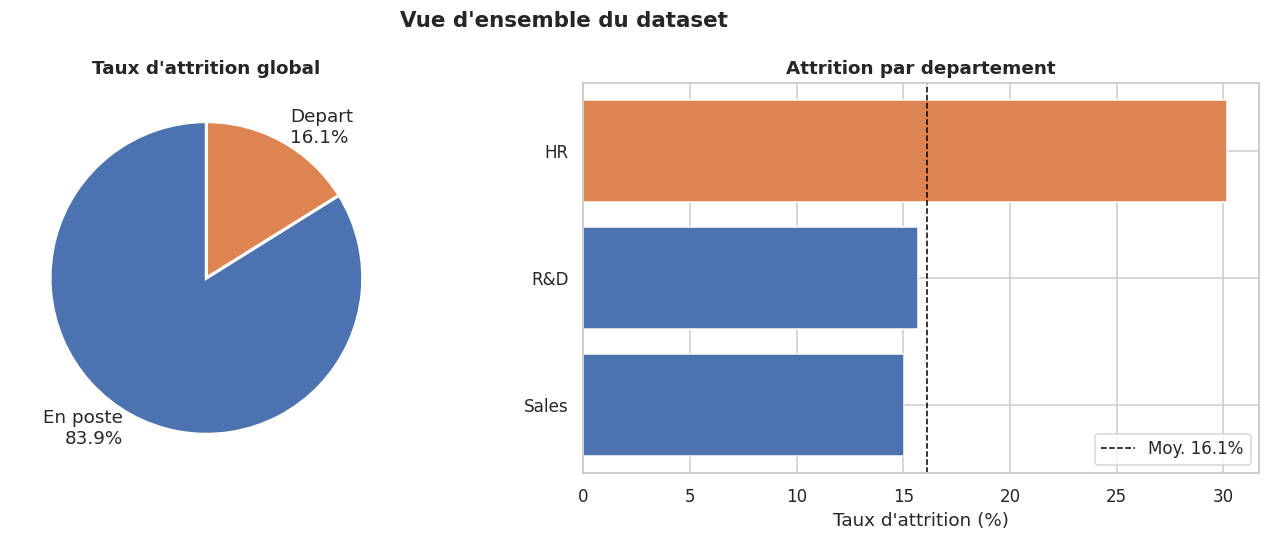

In [2]:
df = pd.read_csv(DATA_PATH)

n_total = len(df)
n_left  = int(df[TARGET_COL].sum())
rate    = n_left / n_total

print(f"Employes analyses  : {n_total:,}")
print(f"Departs observes   : {n_left:,} ({rate:.1%})")
print(f"Variables disponibles : {df.shape[1]}")
print(f"Periode              : 2015 (badges) - 2016 (departs)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Vue d'ensemble du dataset", fontsize=14, fontweight='bold')

# Pie chart attrition
counts = df[TARGET_COL].value_counts().sort_index()
pcts   = counts / counts.sum() * 100
axes[0].pie(
    counts.values,
    labels=[f"{LABELS[k]}\n{pcts[k]:.1f}%" for k in counts.index],
    colors=[PALETTE[k] for k in counts.index],
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    textprops={'fontsize': 12},
)
axes[0].set_title("Taux d'attrition global", fontweight='bold')

# Repartition par departement
dept_counts = df.groupby('department')[TARGET_COL].agg(['sum', 'count'])
dept_counts['rate'] = dept_counts['sum'] / dept_counts['count'] * 100
dept_counts = dept_counts.sort_values('rate', ascending=True)
colors_dept = [PALETTE[1] if r > rate * 100 else PALETTE[0] for r in dept_counts['rate']]
axes[1].barh(dept_counts.index, dept_counts['rate'], color=colors_dept, edgecolor='white')
axes[1].axvline(rate * 100, color='black', linewidth=1, linestyle='--',
                label=f"Moy. {rate*100:.1f}%")
axes[1].set_xlabel("Taux d'attrition (%)")
axes[1].set_title("Attrition par departement", fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()


---
## **2. Profil de l'Employe a Risque**

L'analyse exploratoire a permis d'identifier les signaux les plus discriminants. 
Le profil synthetique d'un employe susceptible de partir est le suivant :

| Dimension | Signal detecte |
|---|---|
| **Role & departement** | Sales Executive & Lab Technician dans Sales / HR sur-representes |
| **Niveau hierarchique** | Niveaux bas (1-2) partent davantage |
| **Salaire** | Salaire median plus faible chez les partants |
| **Anciennete** | Moins d'annees dans l'entreprise et d'experience totale |
| **Promotion** | Stagnation plus marquee (plus d'annees sans promotion) |
| **Voyages** | Deplacements frequents -> taux d'attrition plus eleve |
| **Heures sup.** | Taux d'heures supplementaires nettement plus eleve |
| **Satisfaction** | Scores plus faibles sur job, environnement, equilibre vie pro/perso |

**Profil typique :** employe junior, faiblement remunere, peu de perspectives de promotion, 
voyageant frequemment, avec de nombreuses heures supplementaires et une satisfaction degradee.

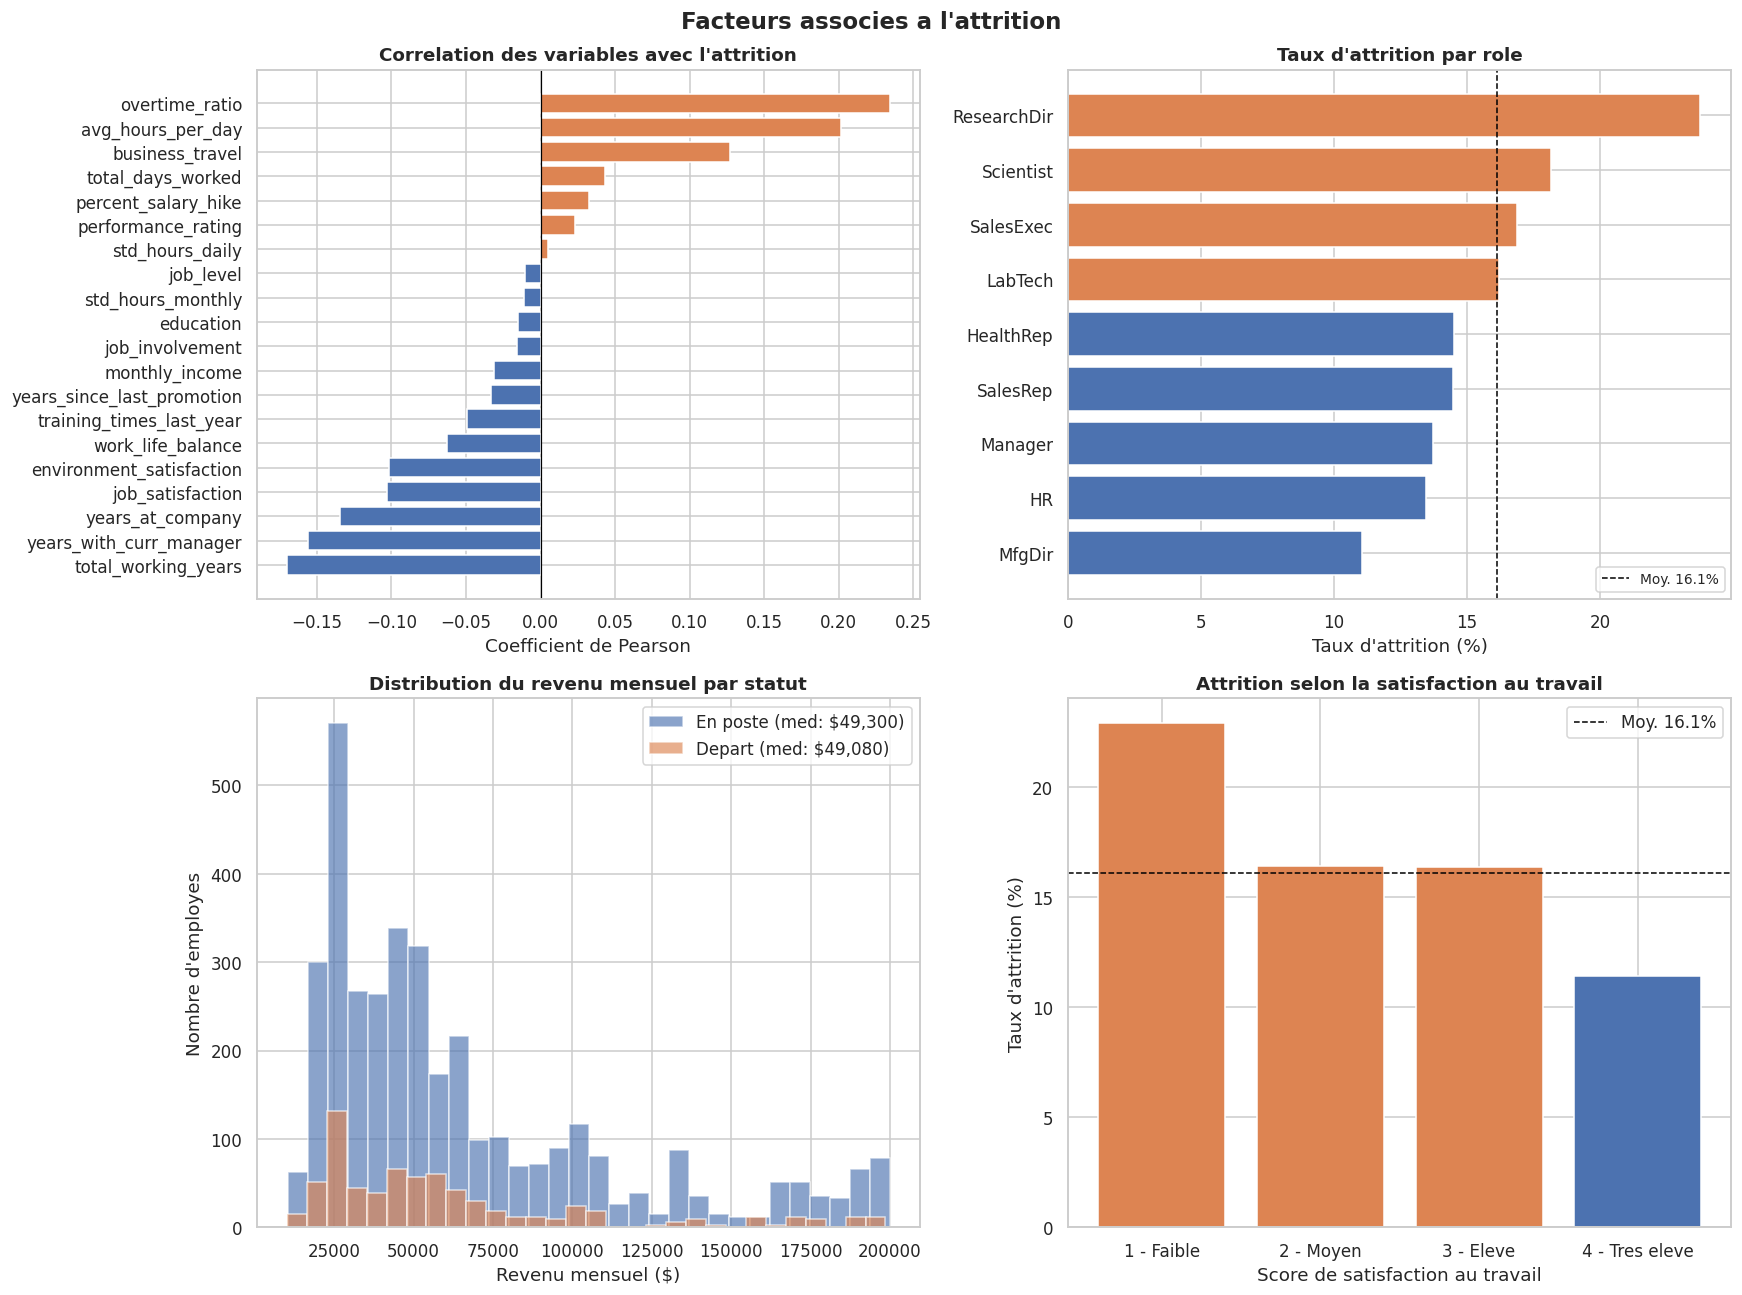

In [3]:
mean_rate = df[TARGET_COL].mean() * 100

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Facteurs associes a l'attrition", fontsize=15, fontweight='bold')

# --- Plot 1 : Correlation avec la cible ---
num_cols = df.select_dtypes(include='number').columns.tolist()
corr = df[num_cols].corr()[TARGET_COL].drop(TARGET_COL).sort_values()
colors_corr = [PALETTE[1] if v > 0 else PALETTE[0] for v in corr.values]
axes[0, 0].barh(corr.index, corr.values, color=colors_corr, edgecolor='white')
axes[0, 0].axvline(0, color='black', linewidth=0.8)
axes[0, 0].set_title('Correlation des variables avec l\'attrition', fontweight='bold')
axes[0, 0].set_xlabel('Coefficient de Pearson')

# --- Plot 2 : Attrition par role ---
rates_role = (df.groupby('job_role')[TARGET_COL]
              .agg(['sum', 'count'])
              .assign(rate=lambda x: x['sum'] / x['count'] * 100)
              .sort_values('rate', ascending=True))
colors_role = [PALETTE[1] if r > mean_rate else PALETTE[0] for r in rates_role['rate']]
axes[0, 1].barh(rates_role.index, rates_role['rate'], color=colors_role, edgecolor='white')
axes[0, 1].axvline(mean_rate, color='black', linewidth=1, linestyle='--',
                   label=f"Moy. {mean_rate:.1f}%")
axes[0, 1].set_title('Taux d\'attrition par role', fontweight='bold')
axes[0, 1].set_xlabel('Taux d\'attrition (%)')
axes[0, 1].legend(fontsize=9)

# --- Plot 3 : Revenu mensuel ---
for status, label in [(0, 'En poste'), (1, 'Depart')]:
    subset = df[df[TARGET_COL] == status]['monthly_income']
    axes[1, 0].hist(subset, bins=30, alpha=0.65,
                    label=f'{label} (med: ${subset.median():,.0f})',
                    color=PALETTE[status], edgecolor='white')
axes[1, 0].set_xlabel('Revenu mensuel ($)')
axes[1, 0].set_ylabel('Nombre d\'employes')
axes[1, 0].set_title('Distribution du revenu mensuel par statut', fontweight='bold')
axes[1, 0].legend()

# --- Plot 4 : Satisfaction au travail ---
sat_map = {1: '1 - Faible', 2: '2 - Moyen', 3: '3 - Eleve', 4: '4 - Tres eleve'}
sat_rates = (df.groupby('job_satisfaction')[TARGET_COL]
             .agg(['sum', 'count'])
             .assign(rate=lambda x: x['sum'] / x['count'] * 100))
sat_rates.index = [sat_map.get(i, str(i)) for i in sat_rates.index]
colors_sat = [PALETTE[1] if r > mean_rate else PALETTE[0] for r in sat_rates['rate']]
axes[1, 1].bar(sat_rates.index, sat_rates['rate'], color=colors_sat, edgecolor='white')
axes[1, 1].axhline(mean_rate, color='black', linewidth=1, linestyle='--',
                   label=f"Moy. {mean_rate:.1f}%")
axes[1, 1].set_xlabel('Score de satisfaction au travail')
axes[1, 1].set_ylabel('Taux d\'attrition (%)')
axes[1, 1].set_title('Attrition selon la satisfaction au travail', fontweight='bold')
axes[1, 1].legend()

plt.tight_layout()
plt.show()


---
## **3. Demarche de Modelisation**

### Principe general

Le modele est entraine sur 80 % des donnees et evalue sur les 20 % restants, 
jamais vus pendant l'apprentissage. La stratification garantit que les deux ensembles 
contiennent la meme proportion de departs (~15 %).

### Modeles evalues

Cinq classifieurs classiques et un reseau de neurones ont ete compares dans des 
conditions identiques (meme split, meme validation croisee a 5 folds, meme metrique).

| Modele | Adapte aux donnees tabulaires | Interpretable | Gestion desequilibre |
|---|:---:|:---:|:---:|
| Regression logistique | Oui | Oui (coefficients) | Oui |
| Random Forest | Oui | Oui (importances) | Oui |
| Extra Trees | Oui | Oui (importances) | Oui |
| Gradient Boosting | Oui | Oui (importances) | Partiel |
| SVM (RBF) | Oui | Non | Oui |
| MLP (reseau de neurones) | Non optimal | Non (boite noire) | Non |

### Pourquoi le MLP est exclu

Sur un dataset tabulaire de ~4 400 lignes, le MLP ne dispose pas d'un biais inductif 
utile (contrairement aux CNN sur images ou RNN sur sequences). De plus, il ne peut pas 
expliquer ses predictions, ce qui est incompatible avec les exigences de transparence 
de l'EU AI Act (Art. 13 & 14) pour un systeme RH classe a haut risque.

### Metrique de selection

Le **F1-Score** est utilise pour selectionner le meilleur modele : il equilibre le 
recall (ne pas manquer de departs) et la precision (ne pas alerter inutilement). 
Le **ROC-AUC** sert a optimiser les hyperparametres en validation croisee (independant du seuil).

---
## **4. Comparaison des Modeles**

Les resultats ci-dessous sont issus de l'evaluation sur le jeu de test (20 % des donnees). 
La meilleure valeur de chaque colonne est mise en evidence.

In [4]:
# Chargement des resultats sauvegardes par 05_modeling.ipynb
results_df = pd.read_csv(RESULTS_PATH, index_col='modele')

display_cols = {
    'recall'      : 'Recall',
    'precision'   : 'Precision',
    'f1'          : 'F1-Score',
    'roc_auc'     : 'ROC-AUC',
    'cv_roc_auc'  : 'CV ROC-AUC',
    'train_time_s': 'Temps train (s)',
    'predict_ms'  : 'Temps pred. (ms)',
}
table = results_df[list(display_cols.keys())].rename(columns=display_cols)

def highlight_best(s):
    if s.name in ['Temps train (s)', 'Temps pred. (ms)']:
        best = s.min()
        return ['background-color: #c8e6c9; font-weight: bold' if v == best else '' for v in s]
    best = s.max()
    return ['background-color: #ffccbc; font-weight: bold' if v == best else '' for v in s]

styled = (
    table.style
    .apply(highlight_best)
    .format({
        'Recall'        : '{:.3f}',
        'Precision'     : '{:.3f}',
        'F1-Score'      : '{:.3f}',
        'ROC-AUC'       : '{:.3f}',
        'CV ROC-AUC'    : '{:.3f}',
        'Temps train (s)': '{:.1f}s',
        'Temps pred. (ms)': '{:.2f}ms',
    })
    .set_caption('Comparaison des modeles - meilleure valeur en evidence')
    .set_table_styles([{'selector': 'caption', 'props': 'caption-side: top; font-size: 13px; font-weight: bold;'}])
)

best_model_name = results_df['f1'].idxmax()
print(f"Meilleur modele (F1-Score) : {best_model_name}")
display(styled)


FileNotFoundError: [Errno 2] No such file or directory: '../data/processed/model_results.csv'

In [ ]:
# Graphique comparatif des metriques cles
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Comparaison des performances", fontsize=14, fontweight='bold')

metrics = [('f1', 'F1-Score'), ('recall', 'Recall'), ('roc_auc', 'ROC-AUC')]
palette = sns.color_palette('muted', n_colors=len(results_df))

for ax, (col, label) in zip(axes, metrics):
    vals = results_df[col].sort_values(ascending=True)
    colors = ['#DD8452' if idx == best_model_name else '#4C72B0' for idx in vals.index]
    ax.barh(vals.index, vals.values, color=colors, edgecolor='white')
    ax.set_xlim(0, 1)
    ax.set_title(label, fontweight='bold')
    for i, (v, idx) in enumerate(zip(vals.values, vals.index)):
        ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)
    if col == 'f1':
        ax.set_xlabel(f"Orange = meilleur modele ({best_model_name})")

plt.tight_layout()
plt.show()


---
## **5. Performance du Meilleur Modele**

La **matrice de confusion** indique comment le modele classe les employes sur le jeu de test. 
La **courbe ROC** mesure sa capacite a distinguer les partants des non-partants 
quel que soit le seuil de decision.


In [ ]:
# Chargement du modele et reconstruction du jeu de test identique a 05_modeling.ipynb
best_model = joblib.load(MODEL_PATH)

X = df.drop(columns=[TARGET_COL] + COLS_TO_DROP)
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    y_pred  = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Evaluation du modele : {best_model_name}", fontsize=14, fontweight='bold')

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['En poste', 'Depart'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matrice de confusion')

# Courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc_val = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='#DD8452', lw=2, label=f'AUC = {roc_auc_val:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Prediction aleatoire')
axes[1].fill_between(fpr, tpr, alpha=0.08, color='#DD8452')
axes[1].set_xlabel('Taux de faux positifs')
axes[1].set_ylabel('Recall (vrais positifs detectes)')
axes[1].set_title('Courbe ROC')
axes[1].legend()

plt.tight_layout()
plt.show()

# Resume texte
tn, fp, fn, tp = cm.ravel()
print(f"Sur {len(y_test)} employes du jeu de test :")
print(f"  Departs correctement identifies (vrais positifs) : {tp}")
print(f"  Departs manques (faux negatifs)                  : {fn}")
print(f"  Alertes incorrectes (faux positifs)              : {fp}")
print(f"  En poste correctement identifies                 : {tn}")


In [ ]:
# Interpretabilite : variables les plus importantes pour le modele
clf          = best_model.named_steps['classifier']
preprocessor = best_model.named_steps['preprocessor']

numeric_features     = X.select_dtypes(include='number').columns.tolist()
categorical_features = X.select_dtypes(exclude='number').columns.tolist()

ohe          = preprocessor.named_transformers_['cat']
ohe_features = list(ohe.get_feature_names_out(categorical_features))
all_features = numeric_features + ohe_features

fig, ax = plt.subplots(figsize=(11, 7))

if hasattr(clf, 'feature_importances_'):
    importances = pd.Series(clf.feature_importances_, index=all_features)
    top15 = importances.sort_values(ascending=True).tail(15)
    colors_imp = ['#DD8452' if i == top15.idxmax() else '#4C72B0' for i in top15.index]
    top15.plot(kind='barh', ax=ax, color=colors_imp, edgecolor='white')
    ax.set_title(f'Top 15 variables les plus importantes ({best_model_name})', fontweight='bold')
    ax.set_xlabel('Importance relative')
elif hasattr(clf, 'coef_'):
    importances = pd.Series(np.abs(clf.coef_[0]), index=all_features)
    top15 = importances.sort_values(ascending=True).tail(15)
    colors_imp = ['#DD8452' if i == top15.idxmax() else '#4C72B0' for i in top15.index]
    top15.plot(kind='barh', ax=ax, color=colors_imp, edgecolor='white')
    ax.set_title(f'Top 15 variables (coefficients absolus) - {best_model_name}', fontweight='bold')
    ax.set_xlabel('|Coefficient|')
else:
    ax.text(0.5, 0.5, 'Ce modele ne fournit pas d\'importances de variables directement.',
            ha='center', va='center', transform=ax.transAxes, fontsize=12)

plt.tight_layout()
plt.show()


---
## **6. Recommandations RH**

Sur la base des facteurs identifies et des predictions du modele, voici les axes 
d'action prioritaires pour reduire l'attrition :

### 6.1 Actions a court terme

- **Heures supplementaires** : les employes avec un taux eleve d'heures supplementaires 
presentent un risque de depart significativement plus eleve. Mettre en place des alertes 
RH pour les employes depassant regulierement les horaires normaux.

- **Satisfaction au travail** : les scores faibles (1-2 sur 4) sont fortement associes 
aux departs. Des entretiens de suivi systematiques pour les employes avec des scores bas 
permettraient d'intervenir avant la decision de depart.

### 6.2 Actions a moyen terme

- **Plans de carriere** : les employes avec peu d'annees depuis leur derniere promotion 
sont sur-representes parmi les partants. Un programme structure de progression interne 
pour les niveaux 1-2 pourrait reduire significativement l'attrition sur ces profils.

- **Voyages d'affaires** : revoir la politique de deplacement pour les roles a fort taux 
d'attrition (Sales Executive). Proposer des alternatives (visioconference, rotation des 
equipes sur les deplacements).

### 6.3 Utilisation du modele

Le modele peut etre utilise comme **outil d'aide a la decision** : il genere une liste 
d'employes a surveiller en priorite, que les RH peuvent ensuite qualifier avec leur 
connaissance du terrain. Il ne doit pas remplacer le jugement humain ni decider 
automatiquement d'une action sur un employe.

---
## **7. Cadre Ethique & Conformite**

### EU AI Act (Reglement IA de l'UE)

Les systemes d'IA utilises dans les decisions RH sont classes a **haut risque** (Annexe III). 
Cela implique :

- **Art. 13 - Transparence** : le modele retenu (tree-based ou logistique) permet 
d'expliquer chaque prediction via les importances de variables ou les coefficients.

- **Art. 14 - Supervision humaine** : le modele est un outil d'aide a la decision, 
pas un systeme autonome. Toute action sur un employe reste a la discretion du responsable RH.

- **Art. 10 - Qualite des donnees** : les biais potentiels (surrepresentation de certains 
roles ou departements dans les partants) ont ete identifies et documentes.

### RGPD

Les predictions individuelles constituent un traitement de donnees a caractere personnel. 
Les employes concernes ont un **droit a l'explication** (Art. 22) et doivent etre informes 
de l'existence du systeme.

### Equite algorithmique

Les performances du modele doivent etre verifiees par sous-groupe (departement, role, 
niveau hierarchique) pour s'assurer que le recall est homogene. Un recall plus faible 
dans un sous-groupe signifie que les actions de retention seront inegalement distribuees.